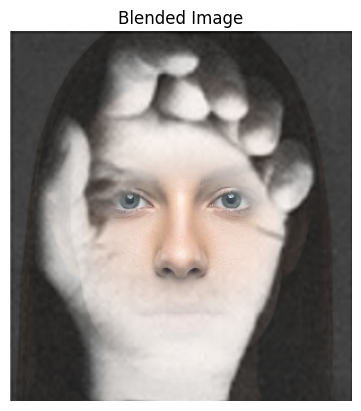

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images (works whether you run from repo root or from CVQuiz02/)
for pa, pb, pm in [
    ("CVLab02/assets/women.png", "CVLab02/assets/hand.png", "CVLab02/assets/oval.png"),
    ("../CVLab02/assets/women.png", "../CVLab02/assets/hand.png", "../CVLab02/assets/oval.png"),
]:
    A, B = cv2.imread(pa), cv2.imread(pb)
    mask = cv2.imread(pm, 0)
    if A is not None and B is not None and mask is not None:
        break
else:
    raise FileNotFoundError("Could not load women/tiger/oval from CVLab02/assets")

H, W = A.shape[:2]
B = cv2.resize(B, (W, H))
mask = (cv2.resize(mask, (W, H)) / 255.0).astype(np.float32)
A = A.astype(np.float32)
B = B.astype(np.float32)

# Gaussian pyramids
levels = 6  # 0..5
G_A, G_B, G_m = [A], [B], [mask]
for _ in range(levels - 1):
    G_A.append(cv2.pyrDown(G_A[-1]))
    G_B.append(cv2.pyrDown(G_B[-1]))
    G_m.append(cv2.pyrDown(G_m[-1]))

# Laplacian pyramids (smallest -> largest)
L_A, L_B = [G_A[-1]], [G_B[-1]]
for i in range(levels - 2, -1, -1):
    size = (G_A[i].shape[1], G_A[i].shape[0])
    L_A.append(G_A[i] - cv2.pyrUp(G_A[i + 1], dstsize=size))
    L_B.append(G_B[i] - cv2.pyrUp(G_B[i + 1], dstsize=size))

# Blend per level (force mask to match level size)
LS = []
for la, lb, gm in zip(L_A, L_B, G_m[::-1]):
    gm = cv2.resize(gm, (la.shape[1], la.shape[0]))
    gm = gm[:, :, None]
    LS.append(la * gm + lb * (1 - gm))

# Reconstruct
img = LS[0]
for i in range(1, len(LS)):
    size = (LS[i].shape[1], LS[i].shape[0])
    img = cv2.pyrUp(img, dstsize=size) + LS[i]

img = np.clip(img, 0, 255).astype(np.uint8)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Blended Image")
plt.axis("off")
plt.show()